---
title: Project 1 — Problem 1
---



In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 1: project_1_problem_1.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Problem 1 
##########################################################################################


## Problem 1


### Import Libraries


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


### Read Database


In [3]:
heart = pd.read_csv("heart1.csv")


## Exploratory Data Analysis on Database


### Find Number of Rows with Missing Data


In [4]:
print("Shape:", heart.shape)
print("\nMissing values:")
print(heart.isnull().sum())


Shape: (270, 14)

Missing values:
age      0
sex      0
cpt      0
rbp      0
sc       0
fbs      0
rer      0
mhr      0
eia      0
opst     0
dests    0
nmvcf    0
thal     0
a1p2     0
dtype: int64


In [5]:
#heart.head()
print(heart.head())


   age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal  a1p2
0   29    1    2  130  204    0    2  202    0   0.0      1      0     3     1
1   34    0    2  118  210    0    0  192    0   0.7      1      0     3     1
2   34    1    1  118  182    0    2  174    0   0.0      1      0     3     1
3   35    1    4  120  198    0    0  130    1   1.6      2      0     7     2
4   35    1    4  126  282    0    2  156    1   0.0      1      0     7     2


In [6]:
print(heart.info())


<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     270 non-null    int64  
 1   sex     270 non-null    int64  
 2   cpt     270 non-null    int64  
 3   rbp     270 non-null    int64  
 4   sc      270 non-null    int64  
 5   fbs     270 non-null    int64  
 6   rer     270 non-null    int64  
 7   mhr     270 non-null    int64  
 8   eia     270 non-null    int64  
 9   opst    270 non-null    float64
 10  dests   270 non-null    int64  
 11  nmvcf   270 non-null    int64  
 12  thal    270 non-null    int64  
 13  a1p2    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB
None


### Descriptive Statistics Table of All Features


In [7]:
print("\nDescriptive statistics:")
heart.describe()
print(heart.describe())



Descriptive statistics:


              age         sex         cpt         rbp          sc         fbs  \
count  270.000000  270.000000  270.000000  270.000000  270.000000  270.000000   
mean    54.433333    0.677778    3.174074  131.344444  249.659259    0.148148   
std      9.109067    0.468195    0.950090   17.861608   51.686237    0.355906   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  213.000000    0.000000   
50%     55.000000    1.000000    3.000000  130.000000  245.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  280.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

              rer         mhr         eia       opst       dests       nmvcf  \
count  270.000000  270.000000  270.000000  270.00000  270.000000  270.000000   
mean     1.022222  149.677778    0.329630    1.05000    1.585185    0.670370   
std      0.997891   23.165717 

### Create Boxplot of Every Variable


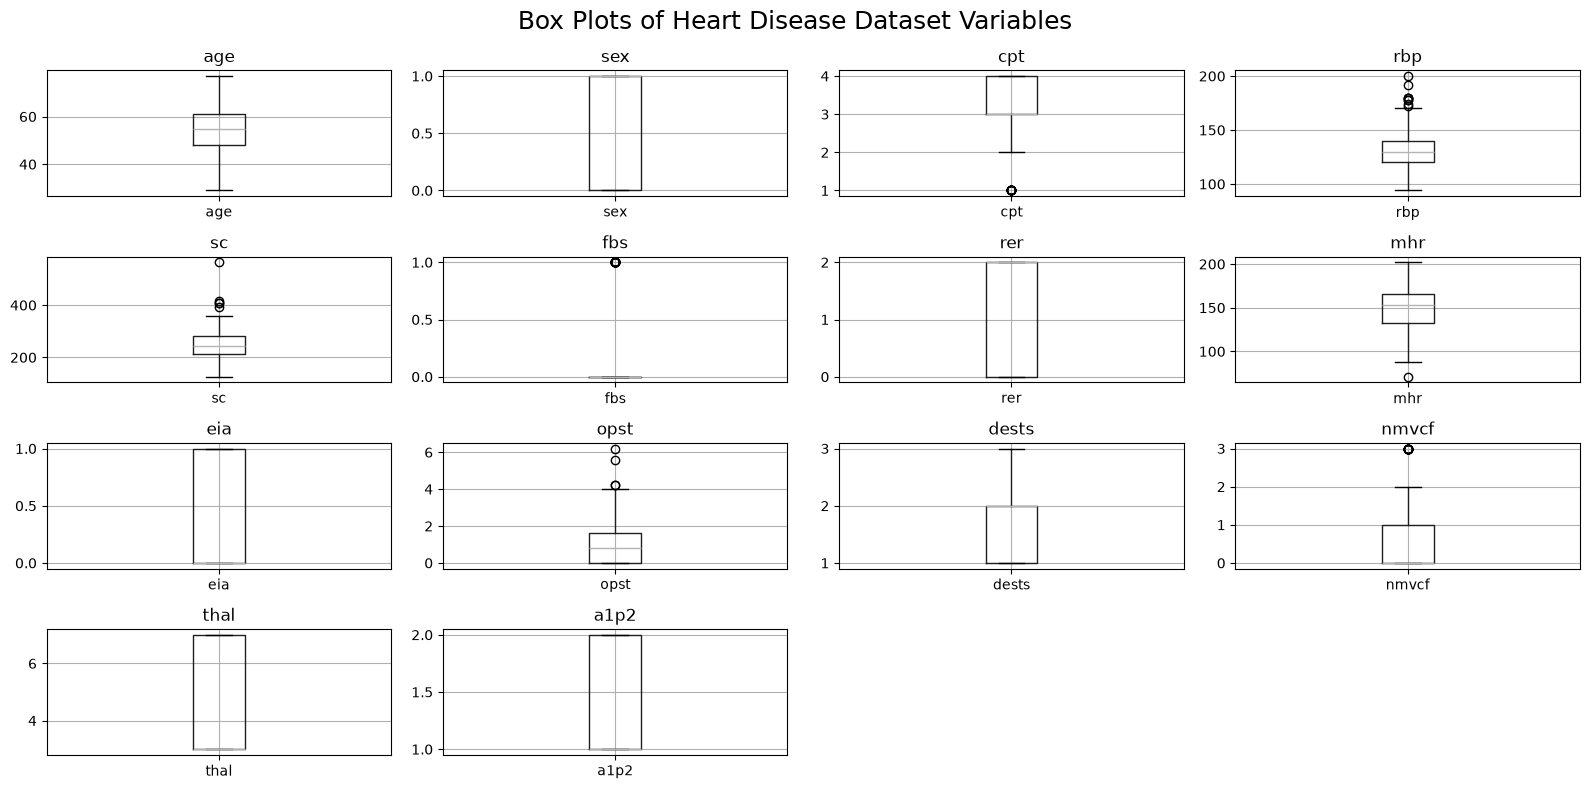

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(heart.columns):
    heart.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(True)

# Hide unused subplots
for i in range(len(heart.columns), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Box Plots of Heart Disease Dataset Variables",
    fontsize=18
)

plt.tight_layout()
plt.show()


## Create Correlation Matrices


In [9]:
# Correlation matrix
corr = heart.corr()
print("\nCorrelation matrix:")
#corr
print(corr)



Correlation matrix:
            age       sex       cpt       rbp        sc       fbs       rer  \
age    1.000000 -0.094401  0.096920  0.273053  0.220056  0.123458  0.128171   
sex   -0.094401  1.000000  0.034636 -0.062693 -0.201647  0.042140  0.039253   
cpt    0.096920  0.034636  1.000000 -0.043196  0.090465 -0.098537  0.074325   
rbp    0.273053 -0.062693 -0.043196  1.000000  0.173019  0.155681  0.116157   
sc     0.220056 -0.201647  0.090465  0.173019  1.000000  0.025186  0.167652   
fbs    0.123458  0.042140 -0.098537  0.155681  0.025186  1.000000  0.053499   
rer    0.128171  0.039253  0.074325  0.116157  0.167652  0.053499  1.000000   
mhr   -0.402215 -0.076101 -0.317682 -0.039136 -0.018739  0.022494 -0.074628   
eia    0.098297  0.180022  0.353160  0.082793  0.078243 -0.004107  0.095098   
opst   0.194234  0.097412  0.167244  0.222800  0.027709 -0.025538  0.120034   
dests  0.159774  0.050545  0.136900  0.142472 -0.005755  0.044076  0.160614   
nmvcf  0.356081  0.086830  0.22

### Create Correlation Matrix Heatmap


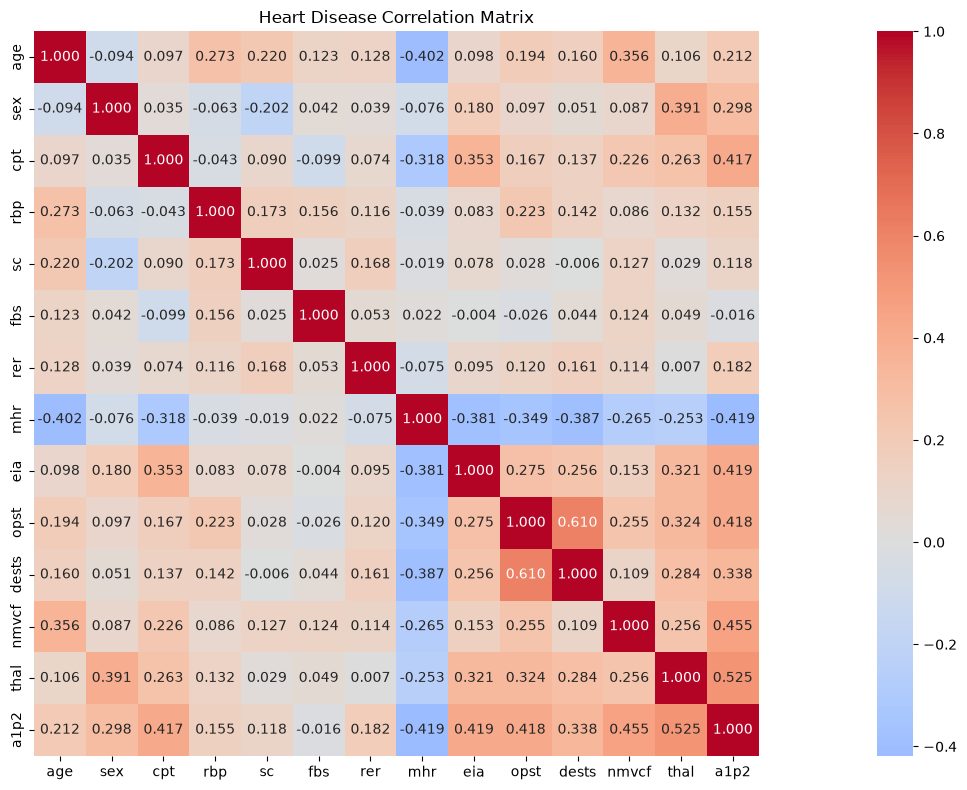

In [10]:
# Create heatmap
plt.figure(figsize=(24,8))
sns.heatmap(
    corr,
    annot=True,        # display correlation values
    cmap='coolwarm',   # red-blue color map
    center=0,          # white at zero correlation
    fmt='.3f',
    square=True
)

plt.title('Heart Disease Correlation Matrix')
plt.tight_layout()
plt.show()


### Show Highest Correlation Features to Target Label


In [11]:
corr_target = corr[['a1p2']].sort_values(by='a1p2', ascending=False)
print(corr_target)


           a1p2
a1p2   1.000000
thal   0.525020
nmvcf  0.455336
eia    0.419303
opst   0.417967
cpt    0.417436
dests  0.337616
sex    0.297721
age    0.212322
rer    0.182091
rbp    0.155383
sc     0.118021
fbs   -0.016319
mhr   -0.418514


### Create Features to Target Correlation Heatmap


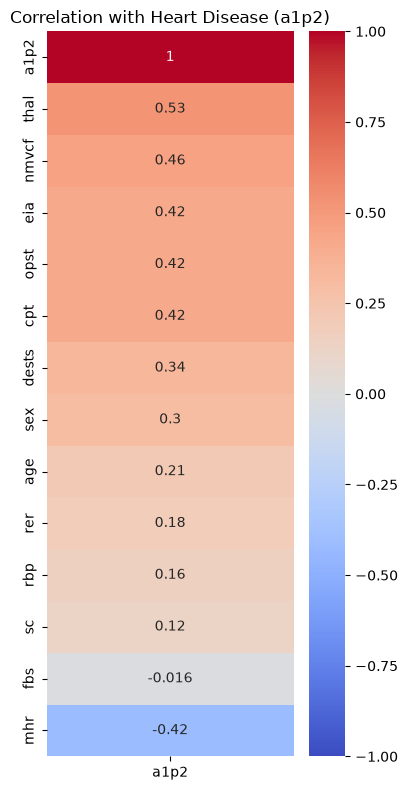

In [12]:
plt.figure(figsize=(4,8))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation with Heart Disease (a1p2)')
plt.tight_layout()
plt.show()


In [13]:
print("\nCorrelation with heart disease variable a1p2:")
print(corr["a1p2"].sort_values(key=lambda x: x.abs(), ascending=False))
print(corr["a1p2"].sort_values(key=lambda x: x, ascending=False))
corr["a1p2"].sort_values(key=lambda x: x, ascending=False)



Correlation with heart disease variable a1p2:
a1p2     1.000000
thal     0.525020
nmvcf    0.455336
eia      0.419303
mhr     -0.418514
opst     0.417967
cpt      0.417436
dests    0.337616
sex      0.297721
age      0.212322
rer      0.182091
rbp      0.155383
sc       0.118021
fbs     -0.016319
Name: a1p2, dtype: float64
a1p2     1.000000
thal     0.525020
nmvcf    0.455336
eia      0.419303
opst     0.417967
cpt      0.417436
dests    0.337616
sex      0.297721
age      0.212322
rer      0.182091
rbp      0.155383
sc       0.118021
fbs     -0.016319
mhr     -0.418514
Name: a1p2, dtype: float64


a1p2     1.000000
thal     0.525020
nmvcf    0.455336
eia      0.419303
opst     0.417967
cpt      0.417436
dests    0.337616
sex      0.297721
age      0.212322
rer      0.182091
rbp      0.155383
sc       0.118021
fbs     -0.016319
mhr     -0.418514
Name: a1p2, dtype: float64

### Show Top Feature Pairwise Correlations


#### Method 1


In [14]:
# Top pairwise correlations, excluding duplicate/self correlations
abs_corr = corr.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
top_corr = upper.stack().sort_values(ascending=False)


In [15]:
print("\nMost highly correlated variable pairs:")
print(top_corr.head(10))



Most highly correlated variable pairs:
opst   dests    0.609712
thal   a1p2     0.525020
nmvcf  a1p2     0.455336
eia    a1p2     0.419303
mhr    a1p2     0.418514
opst   a1p2     0.417967
cpt    a1p2     0.417436
age    mhr      0.402215
sex    thal     0.391046
mhr    dests    0.386847
dtype: float64


#### Method 2


In [16]:
print(corr.values.shape)


(14, 14)


In [17]:
print(*corr.values.shape)


14 14


In [18]:
corr_2 = corr * np.tri(*corr.values.shape, k=-1).T
print(corr_2)


       age       sex       cpt       rbp        sc       fbs       rer  \
age    0.0 -0.094401  0.096920  0.273053  0.220056  0.123458  0.128171   
sex   -0.0  0.000000  0.034636 -0.062693 -0.201647  0.042140  0.039253   
cpt    0.0  0.000000  0.000000 -0.043196  0.090465 -0.098537  0.074325   
rbp    0.0 -0.000000 -0.000000  0.000000  0.173019  0.155681  0.116157   
sc     0.0 -0.000000  0.000000  0.000000  0.000000  0.025186  0.167652   
fbs    0.0  0.000000 -0.000000  0.000000  0.000000  0.000000  0.053499   
rer    0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
mhr   -0.0 -0.000000 -0.000000 -0.000000 -0.000000  0.000000 -0.000000   
eia    0.0  0.000000  0.000000  0.000000  0.000000 -0.000000  0.000000   
opst   0.0  0.000000  0.000000  0.000000  0.000000 -0.000000  0.000000   
dests  0.0  0.000000  0.000000  0.000000 -0.000000  0.000000  0.000000   
nmvcf  0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
thal   0.0  0.000000  0.000000  0.0000

In [19]:
corr_2_abs = corr_2.abs()
print(corr_2_abs)


       age       sex       cpt       rbp        sc       fbs       rer  \
age    0.0  0.094401  0.096920  0.273053  0.220056  0.123458  0.128171   
sex    0.0  0.000000  0.034636  0.062693  0.201647  0.042140  0.039253   
cpt    0.0  0.000000  0.000000  0.043196  0.090465  0.098537  0.074325   
rbp    0.0  0.000000  0.000000  0.000000  0.173019  0.155681  0.116157   
sc     0.0  0.000000  0.000000  0.000000  0.000000  0.025186  0.167652   
fbs    0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.053499   
rer    0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
mhr    0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
eia    0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
opst   0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
dests  0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
nmvcf  0.0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
thal   0.0  0.000000  0.000000  0.0000

In [20]:
corr_2_unstack = corr_2_abs.unstack()
print(corr_2_unstack)


age   age      0.000000
      sex      0.000000
      cpt      0.000000
      rbp      0.000000
      sc       0.000000
                 ...   
a1p2  opst     0.417967
      dests    0.337616
      nmvcf    0.455336
      thal     0.525020
      a1p2     0.000000
Length: 196, dtype: float64


In [21]:
type(corr_2_unstack)


pandas.Series

In [22]:
corr_2_unstack.sort_values(inplace=True, ascending=False)
top_corr_2 = corr_2_unstack.head(15)
print(top_corr_2)


dests  opst     0.609712
a1p2   thal     0.525020
       nmvcf    0.455336
       eia      0.419303
       mhr      0.418514
       opst     0.417967
       cpt      0.417436
mhr    age      0.402215
thal   sex      0.391046
dests  mhr      0.386847
eia    mhr      0.380719
nmvcf  age      0.356081
eia    cpt      0.353160
opst   mhr      0.349045
a1p2   dests    0.337616
dtype: float64


### Create Top 10 Pairwise Correlations Heatmap


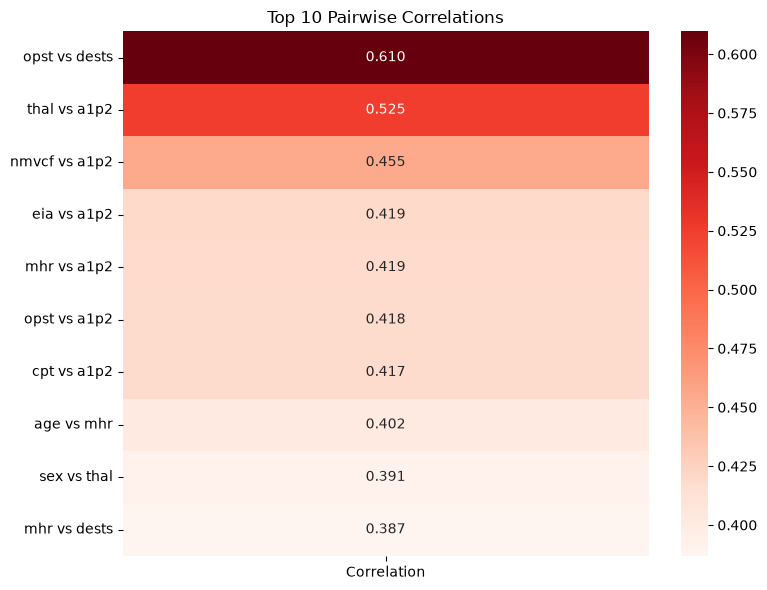

In [23]:
# Top 10 correlations
top10 = top_corr.head(10)

# Convert to dataframe
top_df = pd.DataFrame(
    top10.values,
    index=[f"{a} vs {b}" for a,b in top10.index],
    columns=["Correlation"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    top_df,
    annot=True,
    cmap="Reds",
    fmt=".3f"
)

plt.title("Top 10 Pairwise Correlations")
plt.tight_layout()
plt.show()


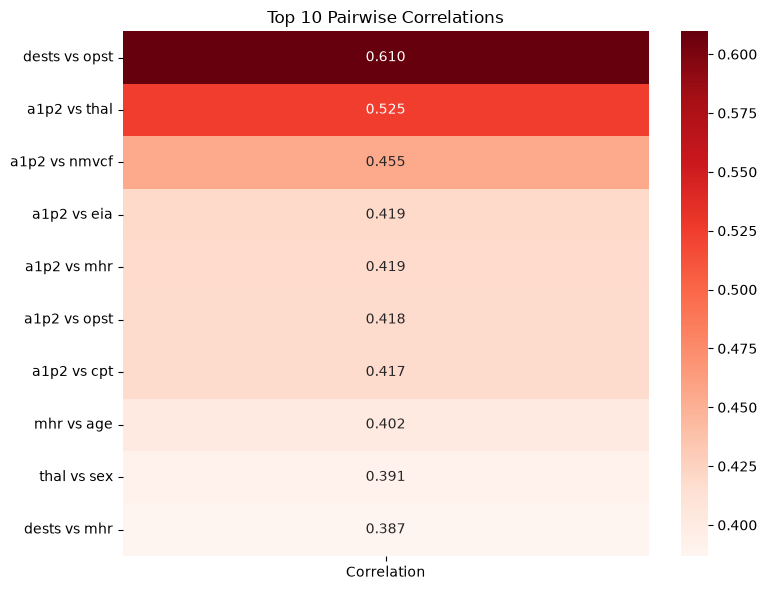

In [24]:
# Top 10 correlations
top10_2 = top_corr_2.head(10)

# Convert to dataframe
top_2_df = pd.DataFrame(
    top10_2.values,
    index=[f"{a} vs {b}" for a,b in top10_2.index],
    columns=["Correlation"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    top_2_df,
    annot=True,
    cmap="Reds",
    fmt=".3f"
)

plt.title("Top 10 Pairwise Correlations")
plt.tight_layout()
plt.show()


## Create Cross - Covariance Matrices


In [25]:
# Cross-covariance matrix
cov = heart.cov()
print("\nCross-covariance matrix:")
print(cov)
#cov



Cross-covariance matrix:
              age       sex       cpt         rbp           sc       fbs  \
age     82.975093 -0.402602  0.838786   44.426394   103.605452  0.400248   
sex     -0.402602  0.219207  0.015407   -0.524287    -4.879719  0.007022   
cpt      0.838786  0.015407  0.902671   -0.733044     4.442434 -0.033320   
rbp     44.426394 -0.524287 -0.733044  319.037051   159.731185  0.989674   
sc     103.605452 -4.879719  4.442434  159.731185  2671.467107  0.463307   
fbs      0.400248  0.007022 -0.033320    0.989674     0.463307  0.126669   
rer      1.165056  0.018340  0.070467    2.070384     8.647005  0.019000   
mhr    -84.874721 -0.825403 -6.992028  -16.193432   -22.437340  0.185461   
eia      0.421685  0.039694  0.158020    0.696448     1.904557 -0.000688   
opst     2.026208  0.052230  0.181970    4.557435     1.640149 -0.010409   
dests    0.894176  0.014539  0.079912    1.563486    -0.182762  0.009638   
nmvcf    3.061586  0.038373  0.202575    1.444816     6.173510

### Create Cross - Covariance Heatmap


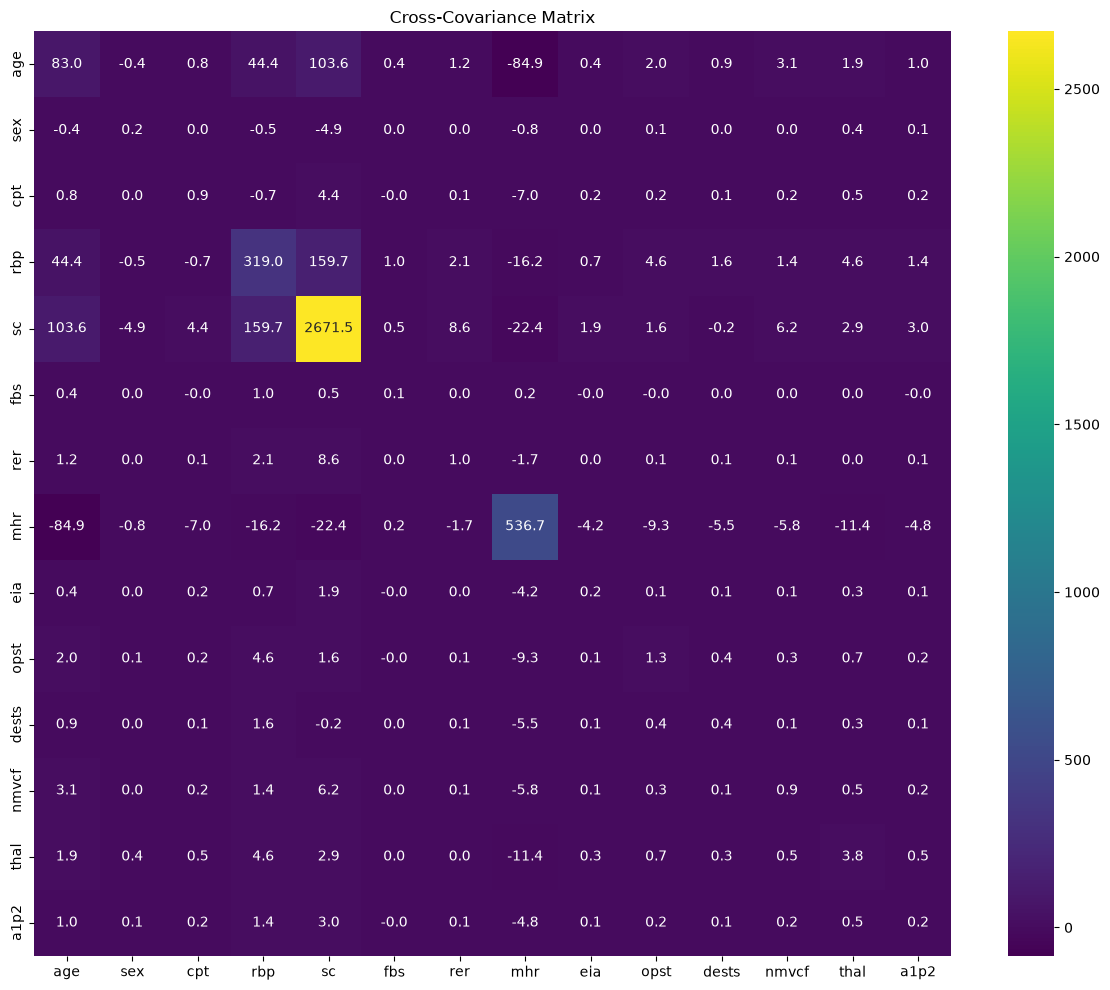

In [26]:
# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    cov,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title("Cross-Covariance Matrix")
plt.tight_layout()
plt.show()


### Extract Top Pairwise Cross - Covariances Between Features


#### Method 1


In [27]:
cov = heart.cov().abs()
print(cov)


              age       sex       cpt         rbp           sc       fbs  \
age     82.975093  0.402602  0.838786   44.426394   103.605452  0.400248   
sex      0.402602  0.219207  0.015407    0.524287     4.879719  0.007022   
cpt      0.838786  0.015407  0.902671    0.733044     4.442434  0.033320   
rbp     44.426394  0.524287  0.733044  319.037051   159.731185  0.989674   
sc     103.605452  4.879719  4.442434  159.731185  2671.467107  0.463307   
fbs      0.400248  0.007022  0.033320    0.989674     0.463307  0.126669   
rer      1.165056  0.018340  0.070467    2.070384     8.647005  0.019000   
mhr     84.874721  0.825403  6.992028   16.193432    22.437340  0.185461   
eia      0.421685  0.039694  0.158020    0.696448     1.904557  0.000688   
opst     2.026208  0.052230  0.181970    4.557435     1.640149  0.010409   
dests    0.894176  0.014539  0.079912    1.563486     0.182762  0.009638   
nmvcf    3.061586  0.038373  0.202575    1.444816     6.173510  0.041581   
thal     1.8

In [28]:
upper = cov.where(
    np.triu(np.ones(cov.shape), k=1).astype(bool)
)

top_cov = (
    upper.stack()
         .sort_values(ascending=False)
)
print("Top Cross - Covariances")
print(top_cov.head(20))


Top Cross - Covariances
rbp  sc       159.731185
age  sc       103.605452
     mhr       84.874721
     rbp       44.426394
sc   mhr       22.437340
rbp  mhr       16.193432
mhr  thal      11.391904
     opst       9.260037
sc   rer        8.647005
cpt  mhr        6.992028
sc   nmvcf      6.173510
mhr  nmvcf      5.801776
     dests      5.505907
sex  sc         4.879719
mhr  a1p2       4.826518
rbp  thal       4.577117
     opst       4.557435
cpt  sc         4.442434
mhr  eia        4.153614
age  nmvcf      3.061586
dtype: float64


#### Method 2


In [29]:
print(cov.values.shape)


(14, 14)


In [30]:
cov_2 = cov * np.tri(*cov.values.shape, k=-1).T
print(cov_2)
#cov_2


       age       sex       cpt        rbp          sc       fbs       rer  \
age    0.0  0.402602  0.838786  44.426394  103.605452  0.400248  1.165056   
sex    0.0  0.000000  0.015407   0.524287    4.879719  0.007022  0.018340   
cpt    0.0  0.000000  0.000000   0.733044    4.442434  0.033320  0.070467   
rbp    0.0  0.000000  0.000000   0.000000  159.731185  0.989674  2.070384   
sc     0.0  0.000000  0.000000   0.000000    0.000000  0.463307  8.647005   
fbs    0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.019000   
rer    0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   
mhr    0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   
eia    0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   
opst   0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   
dests  0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   
nmvcf  0.0  0.000000  0.000000   0.000000    0.000000  0.000000  0.000000   

In [31]:
cov_2_unstack = cov_2.unstack()
print(cov_2_unstack)


age   age      0.000000
      sex      0.000000
      cpt      0.000000
      rbp      0.000000
      sc       0.000000
                 ...   
a1p2  opst     0.238290
      dests    0.103263
      nmvcf    0.213961
      thal     0.507228
      a1p2     0.000000
Length: 196, dtype: float64


In [32]:
cov_2_unstack_sorted = cov_2_unstack.sort_values(ascending=False)
print("Top Cross - Covariances")
print(cov_2_unstack_sorted.head(10))


Top Cross - Covariances
sc    rbp    159.731185
      age    103.605452
mhr   age     84.874721
rbp   age     44.426394
mhr   sc      22.437340
      rbp     16.193432
thal  mhr     11.391904
opst  mhr      9.260037
rer   sc       8.647005
mhr   cpt      6.992028
dtype: float64


### Create Heatmap of Features with High Covariances


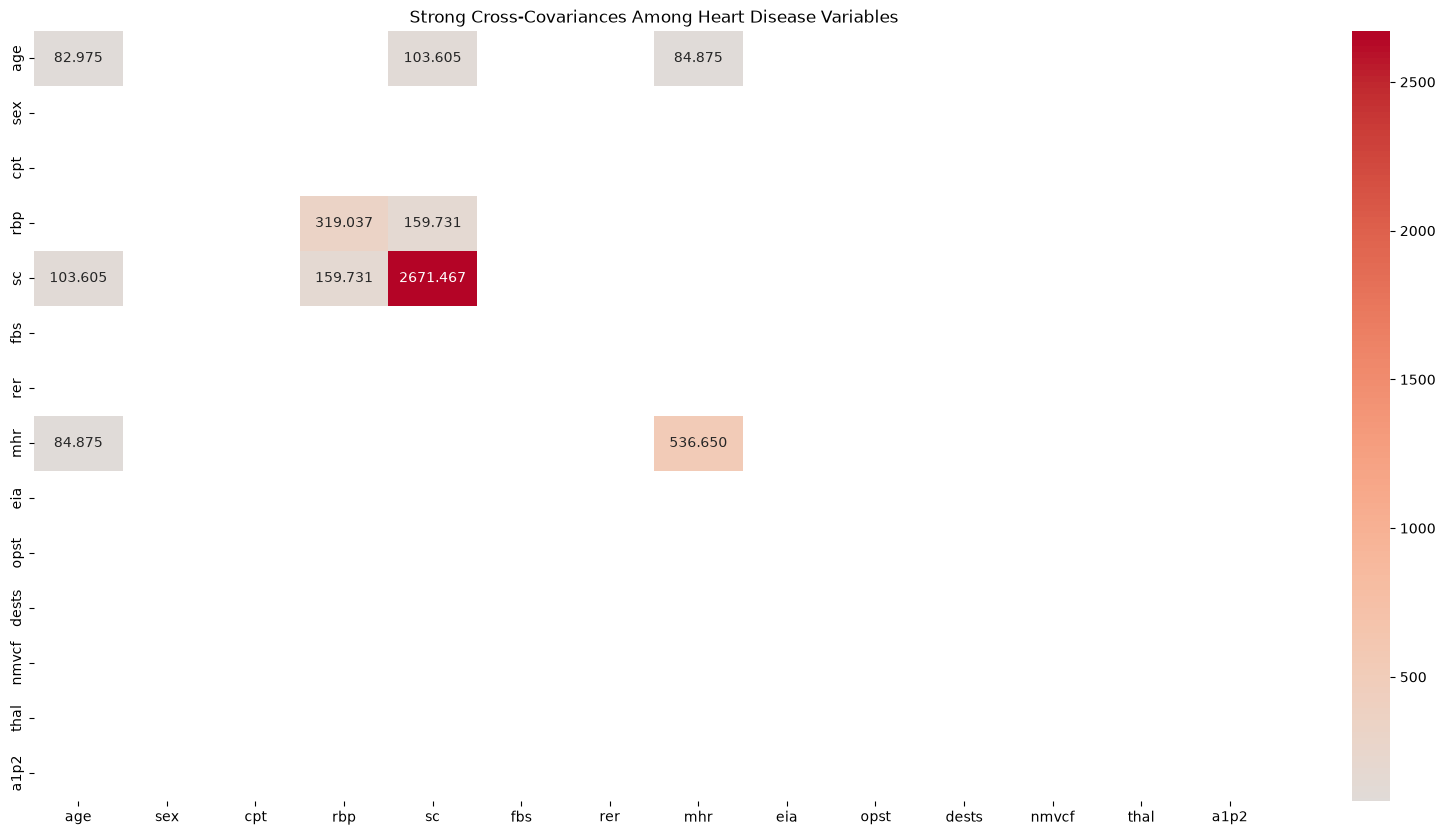

In [33]:
threshold = 50     # choose after inspecting values

mask = np.abs(cov) < threshold

plt.figure(figsize=(20,10))

sns.heatmap(
    cov,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    center=0
)

plt.title(
    'Strong Cross-Covariances Among Heart Disease Variables'
)

plt.show()


### Extract Top Cross - Covariances of Features to Label


In [34]:
print("\nCovariance with heart disease variable a1p2:")
print(cov["a1p2"].sort_values(key=lambda x: x.abs(), ascending=False))



Covariance with heart disease variable a1p2:
mhr      4.826518
sc       3.036762
rbp      1.381660
age      0.962825
thal     0.507228
a1p2     0.247831
opst     0.238290
nmvcf    0.213961
cpt      0.197439
dests    0.103263
eia      0.098306
rer      0.090458
sex      0.069393
fbs      0.002891
Name: a1p2, dtype: float64


### Create Heatmap of Cross - Covariance of Features with Label


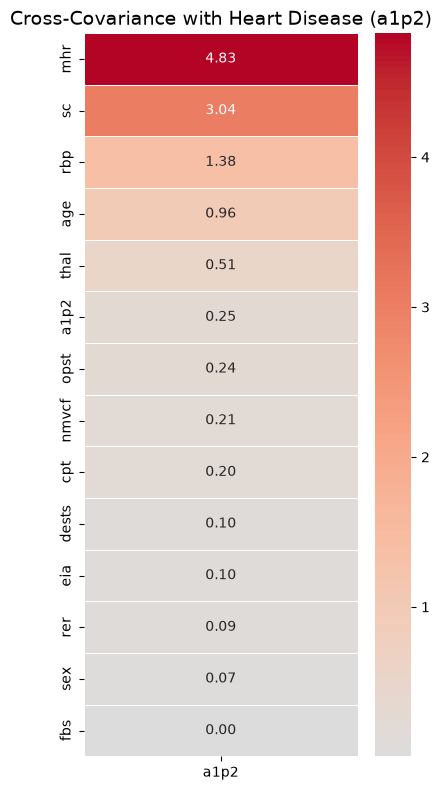

In [35]:
# extract covariance with heart disease
cov_a1p2 = cov[["a1p2"]]

# sort by magnitude
cov_a1p2 = cov_a1p2.reindex(
    cov_a1p2["a1p2"].abs().sort_values(ascending=False).index
)

plt.figure(figsize=(4,8))

sns.heatmap(
    cov_a1p2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Cross-Covariance with Heart Disease (a1p2)",
    fontsize=14
)

plt.tight_layout()
plt.show()


## Create Pair Plot


In [36]:
print("Generating Pair Plot (please be patient...)")


Generating Pair Plot (please be patient...)


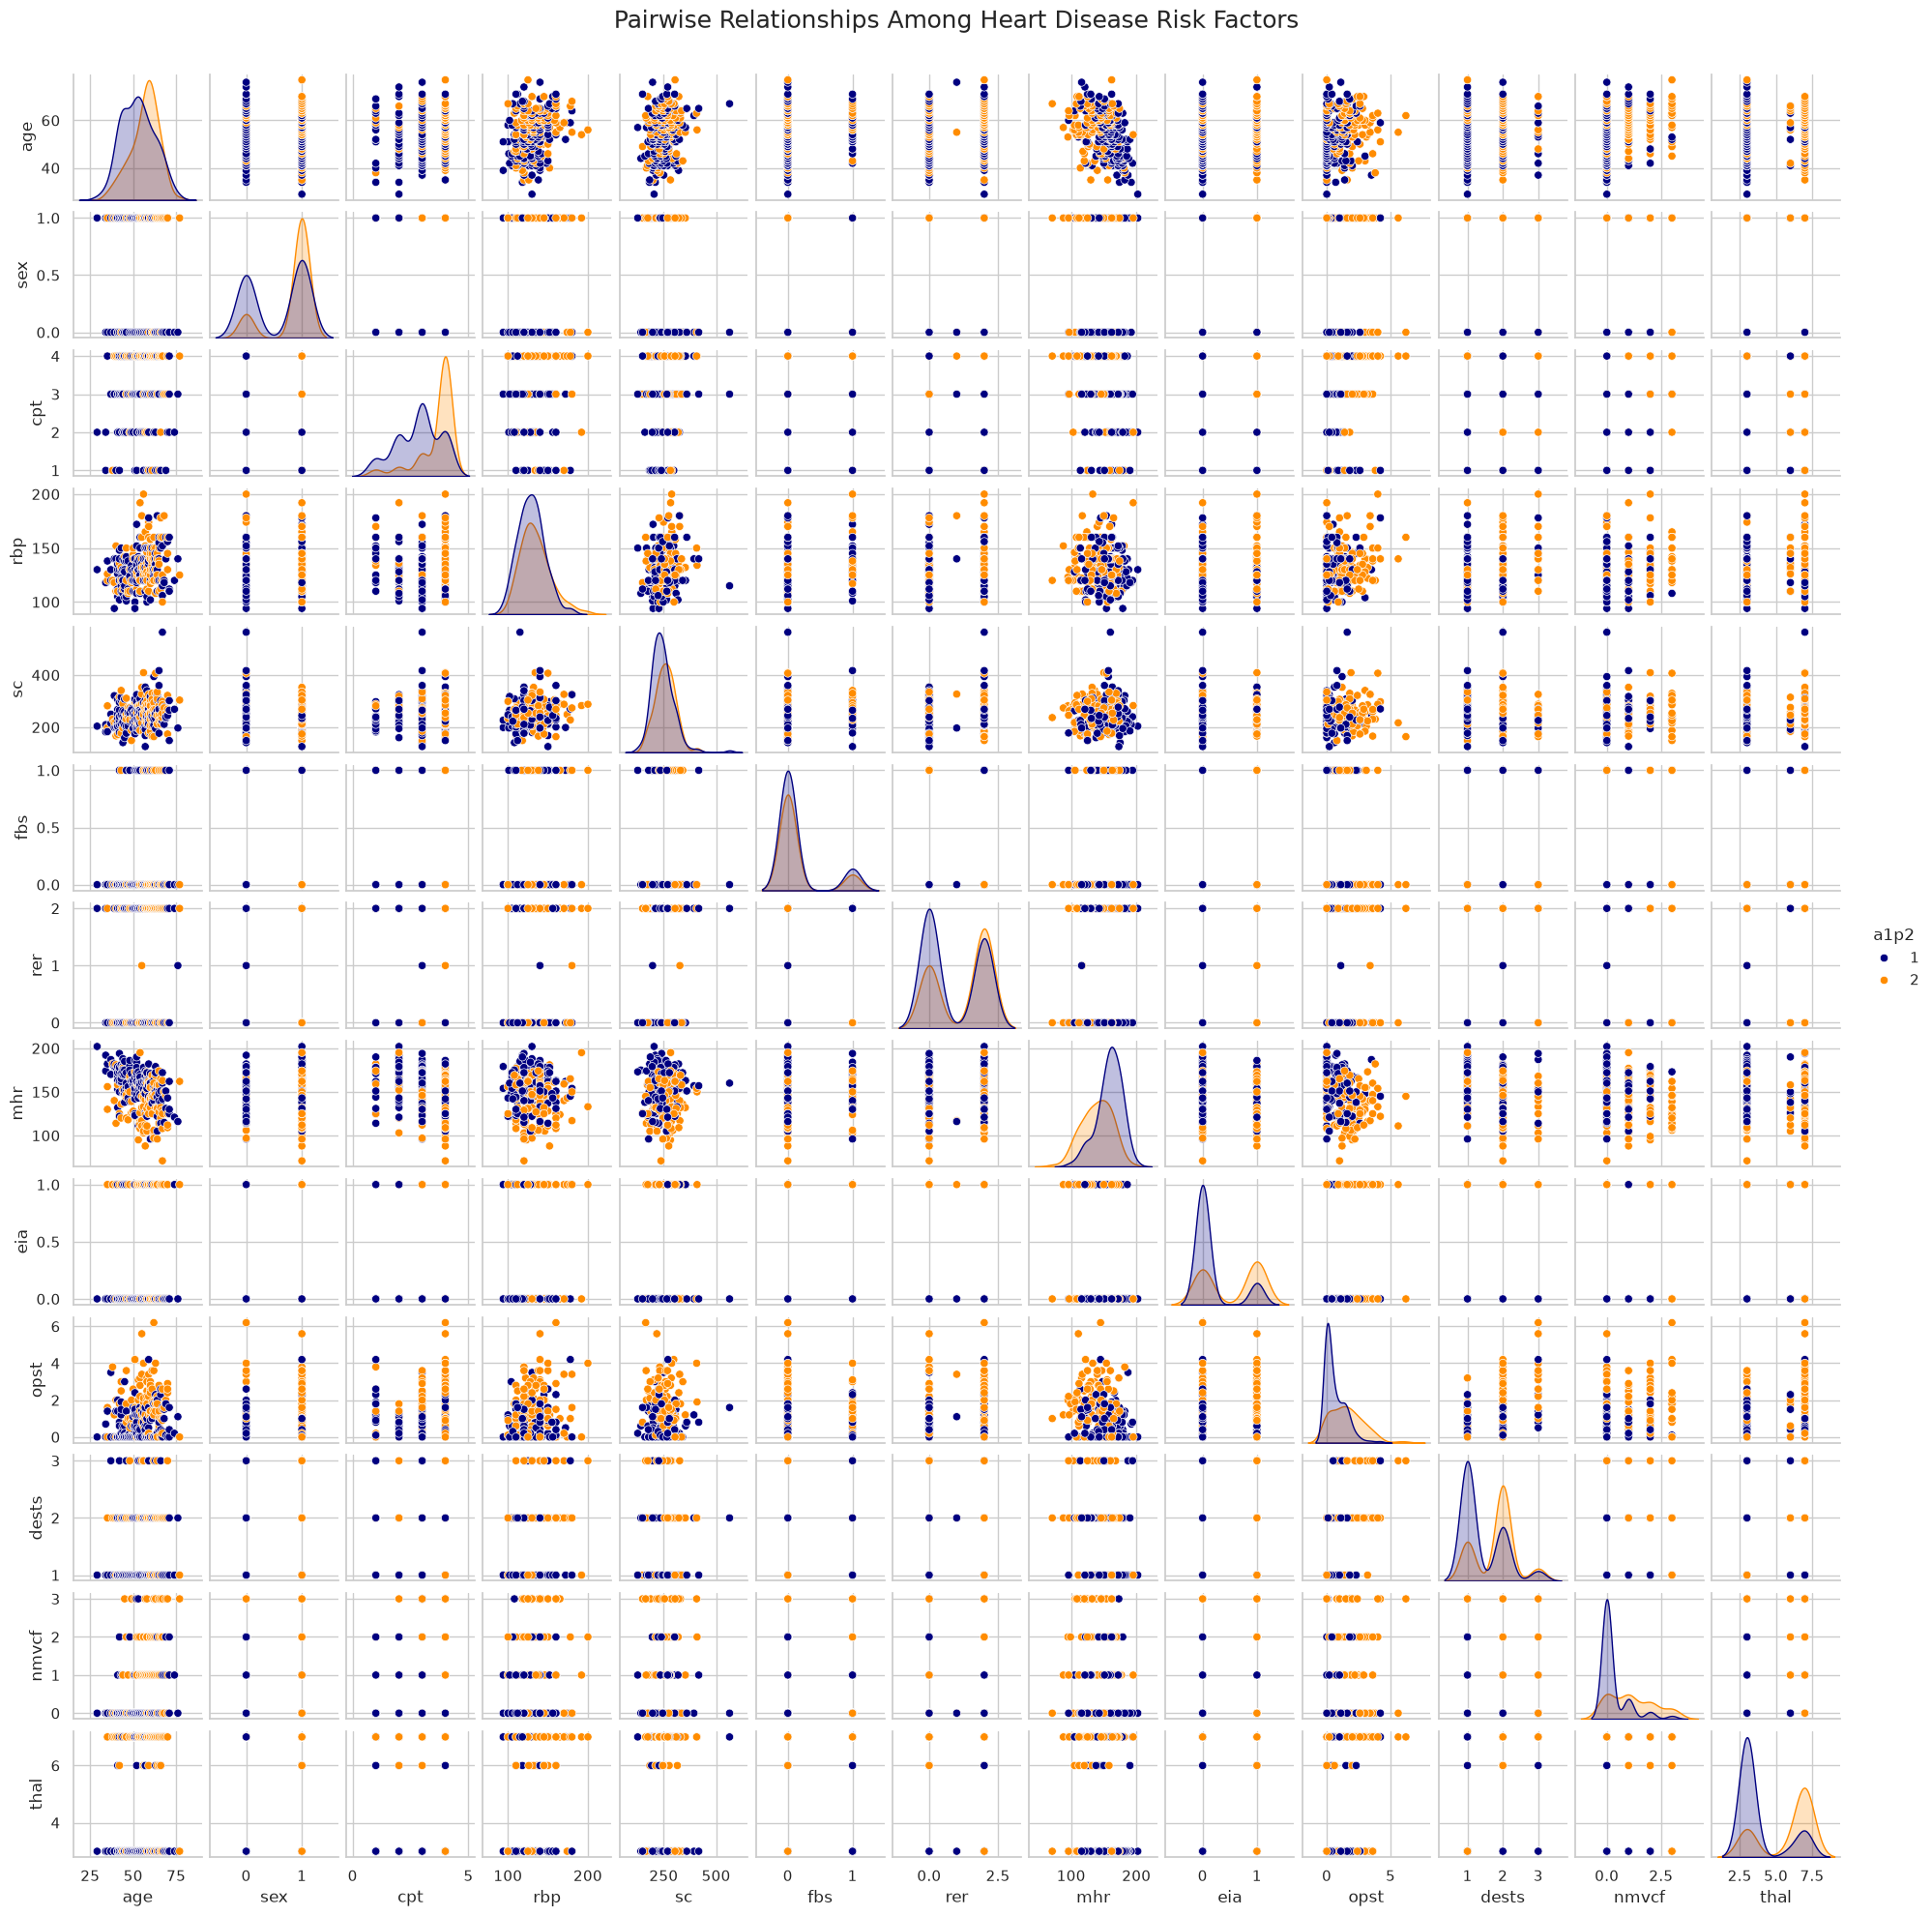

In [37]:
# Pair plot
sns.set(style="whitegrid", context="notebook")
g = sns.pairplot(
    heart, 
    hue="a1p2", 
    height=1.5,
    palette=['navy', 'darkorange']
)

g.fig.suptitle(
    'Pairwise Relationships Among Heart Disease Risk Factors',
    fontsize=18,
    y=1.02
)
plt.show()
